# CSC478 Tutorial 2 — Probability Theory and Estimation

Companion notebook to **Lecture 2: Probability Theory and Estimation Techniques**.
Every demo has sliders: change a parameter and watch the figure update. Cells marked ✏️ are short
exercises with a collapsed solution directly below (click the `···` bar or *View ▸ Expand All Code*).

**Setup (once, ~2 min):** in this folder run

```
python3 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
jupyter lab 2026-09-17-probability.ipynb
```

then **Run ▸ Run All Cells**. Requires Python 3.10+ (see `README.md` for details).

| Time | Section | Slides | What you will do |
|---|---|---|---|
| 0–5 | 1. Random variables | 4–5 | The PDF quiz, numerically; probability is area, not height |
| 5–12 | 2. Joint, marginal, conditional | 6–7, 10–11 | Slice and sum a 2-D density; ✏️ A |
| 12–18 | 3. Expectation | 9 | Sample averages; linearity survives correlation |
| 18–28 | 4. Bayes' Theorem | 7–8 | Watch a coin prior become a posterior; ✏️ B the medical test puzzle |
| 28–40 | 5. Linear regression | 14–19 | Normal equations vs. gradient descent in PyTorch; ✏️ C perpendicular error |
| 40–50 | 6. RANSAC | 20–25 | Implement it, watch it, and check the slide-22 formula |
| home | ✏️ D | 21 | Break RANSAC and explain why |

Colour is used consistently throughout: **truth** is dark, **data / prior / inliers** are blue,
**residuals / likelihood / outliers** are red, **fits / posteriors** are teal, and the
**current highlight** (a slider value, a sampled point) is amber.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats, integrate
import ipywidgets as W
from IPython.display import display, Markdown
import torch
from pathlib import Path

%matplotlib inline

# ---- palette (background / foreground from randoma11y; accents checked for colour-vision-deficiency separation)
BG, FG = "#f8fafc", "#0f172a"
ROLE = dict(
    truth=FG, data="#2563eb", prior="#2563eb", inlier="#2563eb",
    residual="#dc2626", likelihood="#dc2626", outlier="#dc2626",
    fit="#0d9488", posterior="#0d9488",
    highlight="#ca8a04", muted="#94a3b8", grid="#e2e8f0",
)
SEQ_CMAP = sns.light_palette(ROLE["data"], as_cmap=True)      # single hue, light -> dark, for densities

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "xtick.color": FG, "ytick.color": FG,
    "axes.edgecolor": FG, "grid.color": ROLE["grid"], "axes.titlelocation": "left",
    "axes.titleweight": "bold", "axes.titlesize": 11, "font.size": 10.5,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
    "font.family": "DejaVu Sans",   # bundled with matplotlib, so figures look the same on every machine
})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def show(fig, save=None):
    "Display a figure; if `save` is given also write figures/02-<save>.pdf (vector)."
    if save:
        fig.savefig(FIG_DIR / f"02-{save}.pdf", bbox_inches="tight")
    plt.show()

def interactive(fn, per_row=3, extra=(), **controls):
    "Wire sliders to a plotting function. The same function is called with plain arguments for static figures."
    out = W.interactive_output(fn, controls)
    ws = list(extra) + list(controls.values())
    rows = [W.HBox(ws[i:i + per_row]) for i in range(0, len(ws), per_row)]
    display(W.VBox(rows), out)

_style = {"description_width": "initial"}
def fslider(value, lo, hi, step, desc, live=True):
    return W.FloatSlider(value=value, min=lo, max=hi, step=step, description=desc, style=_style,
                         continuous_update=live, readout_format=".2f")
def islider(value, lo, hi, desc, step=1, live=True):
    return W.IntSlider(value=value, min=lo, max=hi, step=step, description=desc, style=_style, continuous_update=live)
def logslider(value, lo_exp, hi_exp, desc, live=True):
    return W.FloatLogSlider(value=value, base=10, min=lo_exp, max=hi_exp, step=0.05, description=desc, style=_style,
                            continuous_update=live, readout_format=".4f")

print("numpy", np.__version__, "| torch", torch.__version__, "| ipywidgets", W.__version__)

numpy 2.1.3 | torch 2.10.0 | ipywidgets 8.1.5


## 1. Random variables and probability densities

A **random variable** $X$ takes values that vary due to chance. For a continuous variable the
distribution of values is described by a **probability density function** $p(x)$ with

$$p(x) \ge 0 \quad\text{and}\quad \int_{-\infty}^{\infty} p(x)\,dx = 1 \qquad\text{(second axiom of probability)}.$$

The probability that $X$ lands in an interval is the **area** under the density, not the height:

$$P(a \le X \le b) = \int_a^b p(x)\,dx .$$

For a discrete variable the integral becomes a sum over a probability *mass* function.

### Demo 1.1 — The quiz from slide 5, numerically

Which of the following are PDFs?
(a) $f(x) = 0.5$ on $[0, 2]$, else $0$; (b) $f(x) = x^2$; (c) $f(x) = e^{-x}$ for $x \in \mathbb{R}^+$.
The slider only matters for (b): it sets the domain $[-U, U]$ over which we try to integrate.

In [ ]:
def _a(x): return np.where((x >= 0) & (x <= 2), 0.5, 0.0)
def _b(x): return np.asarray(x, dtype=float) ** 2
def _c(x): return np.where(x >= 0, np.exp(-np.clip(x, 0, None)), 0.0)

QUIZ = {  # name -> (function, support); None = whole real line
    "a) f(x) = 0.5 on [0, 2], else 0": (_a, (0.0, 2.0)),
    "b) f(x) = x²": (_b, None),
    "c) f(x) = exp(−x) for x ≥ 0": (_c, (0.0, np.inf)),
}

def quiz_pdf(which="a) f(x) = 0.5 on [0, 2], else 0", half_width=3.0, save=None):
    f, support = QUIZ[which]
    lo, hi = support if support is not None else (-half_width, half_width)
    area, _ = integrate.quad(lambda t: float(f(np.array(t))), lo, hi)
    xs = np.linspace(-1, 6, 600) if support is not None else np.linspace(-half_width - 0.5, half_width + 0.5, 600)
    ys = f(xs)
    nonneg = bool(np.all(ys >= 0))
    is_pdf = nonneg and np.isclose(area, 1.0, atol=1e-6)

    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.plot(xs, ys, color=ROLE["data"])
    ax.fill_between(xs, 0, ys, where=(xs >= lo) & (xs <= hi), color=ROLE["data"], alpha=0.2, lw=0)
    hi_txt = "∞" if np.isinf(hi) else f"{hi:g}"
    verdict = "✓ a valid PDF" if is_pdf else "✗ not a PDF"
    ax.set_title(f"{which}\n∫ f(x) dx over [{lo:g}, {hi_txt}] = {area:.3f}   ·   non-negative: {'yes' if nonneg else 'no'}   →   {verdict}")
    if support is None:
        ax.text(0.02, 0.95, "The area grows without bound as U increases,\nso x² cannot be normalised on ℝ.",
                transform=ax.transAxes, va="top", fontsize=9, color=ROLE["residual"])
    ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.set_ylim(bottom=0)
    show(fig, save)

interactive(quiz_pdf,
            which=W.Dropdown(options=list(QUIZ), description="function", style=_style),
            half_width=fslider(3.0, 1.0, 10.0, 0.5, "U (domain half-width, for b only)"))

Output()

### Demo 1.2 — Probability is area, not height

A Gaussian $\mathcal{N}(\mu, \sigma^2)$ with the interval $[a, b]$ shaded. Make $\sigma$ small and the
density rises above 1 — a density value is not a probability; only the area is.
The grey histogram shows $N$ samples: the fraction of samples inside $[a, b]$ approaches the shaded area.

In [ ]:
def gaussian_area(mu=0.0, sigma=1.0, interval=(-1.0, 1.0), n_samples=200, save=None):
    a, b = interval
    dist = stats.norm(mu, sigma)
    xs = np.linspace(-6, 6, 800); pdf = dist.pdf(xs)
    prob = dist.cdf(b) - dist.cdf(a)
    samples = np.random.default_rng(0).normal(mu, sigma, n_samples)
    frac = np.mean((samples >= a) & (samples <= b))

    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.hist(samples, bins=48, range=(-6, 6), density=True, color=ROLE["muted"], alpha=0.45, lw=0,
            label=f"{n_samples} samples, fraction in [a, b] = {frac:.3f}")
    ax.plot(xs, pdf, color=ROLE["data"], label=f"p(x) = N({mu:g}, {sigma:g}²)")
    ax.fill_between(xs, 0, pdf, where=(xs >= a) & (xs <= b), color=ROLE["data"], alpha=0.25, lw=0,
                    label=f"area = P({a:g} ≤ X ≤ {b:g}) = {prob:.3f}")
    ax.axhline(1, color=ROLE["muted"], ls=":", lw=1)
    ax.text(-5.9, 1.02, "density = 1", ha="left", va="bottom", color=ROLE["muted"], fontsize=9)
    if pdf.max() > 1:
        ax.text(0.02, 0.80, f"peak density {pdf.max():.2f} > 1 — allowed, because\nthe density is not a probability",
                transform=ax.transAxes, va="top", fontsize=9, color=ROLE["residual"])
    ax.set_ylim(0, max(1.15 * pdf.max(), 1.15)); ax.set_xlim(-6, 6)
    ax.set_xlabel("x"); ax.set_ylabel("density"); ax.legend(loc="upper right", fontsize=9)
    ax.set_title("Probability is the area under p(x)")
    show(fig, save)

interactive(gaussian_area,
            mu=fslider(0.0, -3.0, 3.0, 0.1, "μ"),
            sigma=fslider(1.0, 0.2, 2.5, 0.05, "σ"),
            interval=W.FloatRangeSlider(value=(-1.0, 1.0), min=-6, max=6, step=0.1, description="[a, b]", style=_style, readout_format=".1f"),
            n_samples=islider(200, 10, 5000, "N samples", step=10))

Output()

## 2. Joint, marginal, and conditional probability

With two random variables we work with the **joint density** $p(x, y)$. From it we can recover either
variable alone by **marginalisation** — summing (integrating) the other one out — and the distribution of
one variable given a known value of the other by **conditioning**:

$$p(x) = \int p(x, y)\,dy, \qquad p(x \mid y = y^*) = \frac{p(x, y^*)}{p(y^*)}, \qquad p(x, y) = p(x \mid y)\,p(y).$$

Our running example is the 2-D Gaussian from slide 11,
$p(\mathbf{x}) = \frac{1}{2\pi\sqrt{|\Sigma|}} \exp\!\left(-\tfrac12 (\mathbf{x}-\boldsymbol\mu)^T \Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)\right)$
with covariance $\Sigma = \begin{bmatrix}\sigma_x^2 & \rho\sigma_x\sigma_y\\ \rho\sigma_x\sigma_y & \sigma_y^2\end{bmatrix}$,
but we evaluate it **on a grid** and do every operation by summation. That way the same three lines of code
work for *any* joint density, Gaussian or not (slide 12 lists other representations: mixtures, histograms, particles).

In [4]:
GX = np.linspace(-4, 4, 161); GY = np.linspace(-4, 4, 161)
DX = GX[1] - GX[0]; DY = GY[1] - GY[0]
XX, YY = np.meshgrid(GX, GY)          # XX[j, i] = GX[i], YY[j, i] = GY[j]: rows index y, columns index x
GRID = np.dstack([XX, YY])

def gaussian_joint(sx=1.0, sy=1.0, rho=0.0):
    cov = [[sx**2, rho * sx * sy], [rho * sx * sy, sy**2]]
    return stats.multivariate_normal([0, 0], cov).pdf(GRID)          # shape (len(GY), len(GX))

def marginals(P):
    "Marginalise on the grid: sum out the other variable, times its grid spacing."
    px = P.sum(axis=0) * DY        # sum over y -> function of x
    py = P.sum(axis=1) * DX        # sum over x -> function of y
    return px, py

def conditional_x_given_y(P, y_star):
    "Slice the joint at the grid row closest to y_star and normalise the slice."
    j = int(np.argmin(np.abs(GY - y_star)))
    slice_ = P[j, :]                     # p(x, y*)  — un-normalised
    p_y_star = slice_.sum() * DX         # p(y*)     — the normaliser (evidence)
    return slice_ / p_y_star, slice_, GY[j]

### Demo 2.1 — Joint density and its marginals

The heatmap is $p(x, y)$; the side panels are the marginals computed as row/column sums.
Change $\rho$: the joint tilts, but the marginals do not move (dashed = the marginals at $\rho = 0$).

In [ ]:
def plot_joint(sx=1.0, sy=1.0, rho=0.6, contours=True, save=None):
    P = gaussian_joint(sx, sy, rho); px, py = marginals(P)
    px0, py0 = marginals(gaussian_joint(sx, sy, 0.0))
    mass = P.sum() * DX * DY

    fig = plt.figure(figsize=(6.6, 6.6))
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 1.3], height_ratios=[1.3, 4], hspace=0.06, wspace=0.06)
    ax = fig.add_subplot(gs[1, 0]); axt = fig.add_subplot(gs[0, 0], sharex=ax); axr = fig.add_subplot(gs[1, 1], sharey=ax)
    ax.pcolormesh(GX, GY, P, cmap=SEQ_CMAP, shading="auto", rasterized=True)
    if contours:
        ax.contour(GX, GY, P, levels=6, colors=FG, linewidths=0.5, alpha=0.5)
    ax.grid(False); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
    axt.plot(GX, px, color=ROLE["data"], label="p(x) = Σ_y p(x, y) Δy")
    axt.plot(GX, px0, color=ROLE["muted"], ls="--", lw=1.2, label="same, at ρ = 0")
    axr.plot(py, GY, color=ROLE["data"]); axr.plot(py0, GY, color=ROLE["muted"], ls="--", lw=1.2)
    axt.tick_params(labelbottom=False); axr.tick_params(labelleft=False)
    axt.set_ylabel("p(x)"); axr.set_xlabel("p(y)")
    axt.legend(loc="upper right", fontsize=8)
    axt.set_title(f"Joint p(x, y) with σx = {sx:g}, σy = {sy:g}, ρ = {rho:g}    ·    Σ p Δx Δy = {mass:.4f}\n"
                  f"Marginals (solid) do not depend on ρ", loc="left")
    show(fig, save)

interactive(plot_joint,
            sx=fslider(1.0, 0.3, 2.0, 0.05, "σx"), sy=fslider(1.0, 0.3, 2.0, 0.05, "σy"),
            rho=fslider(0.6, -0.95, 0.95, 0.05, "ρ"), contours=W.Checkbox(value=True, description="contours"))

Output()

### Demo 2.2 — Conditioning is slicing, then renormalising

Choose $y^*$. The amber line marks the slice $p(x, y^*)$ through the joint. That slice has tiny total area
(it is a density in two variables evaluated at one $y$), so we divide by $p(y^*)$ to get a proper conditional
density in $x$. For a Gaussian the theory gives $E[x \mid y^*] = \rho \frac{\sigma_x}{\sigma_y} y^*$ and
$\text{std}[x \mid y^*] = \sigma_x\sqrt{1-\rho^2}$ — the grid computation should agree.

In [ ]:
def plot_conditional(sx=1.0, sy=1.0, rho=0.6, y_star=1.5, save=None):
    P = gaussian_joint(sx, sy, rho); px, _ = marginals(P)
    cond, slice_, y_used = conditional_x_given_y(P, y_star)
    mean = np.sum(GX * cond) * DX; std = np.sqrt(np.sum((GX - mean)**2 * cond) * DX)
    mean_th = rho * sx / sy * y_used; std_th = sx * np.sqrt(1 - rho**2)

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw=dict(width_ratios=[1, 1.25]))
    ax.pcolormesh(GX, GY, P, cmap=SEQ_CMAP, shading="auto", rasterized=True); ax.grid(False); ax.set_aspect("equal")
    ax.axhline(y_used, color=ROLE["highlight"], lw=2)
    ax.text(3.9, y_used + 0.1, f"y* = {y_used:.2f}", ha="right", color=ROLE["highlight"], fontsize=9)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Joint p(x, y) and the slice y = y*")
    ax2.plot(GX, px, color=ROLE["muted"], ls="--", lw=1.5, label="marginal p(x)  (for comparison)")
    ax2.plot(GX, slice_, color=ROLE["highlight"], lw=1.5, label=f"slice p(x, y*)  — area {slice_.sum()*DX:.3f}, not normalised")
    ax2.plot(GX, cond, color=ROLE["posterior"], lw=2.2, label=f"conditional p(x | y*) = p(x, y*) / p(y*)  — area {cond.sum()*DX:.3f}")
    ax2.axvline(mean, color=ROLE["posterior"], lw=1, ls=":")
    ax2.set_xlabel("x"); ax2.set_ylabel("density"); ax2.legend(loc="upper left", fontsize=8.5)
    ax2.set_title(f"E[x | y*] = {mean:.2f} (theory {mean_th:.2f})   ·   std = {std:.2f} (theory {std_th:.2f})")
    ax2.set_xlim(-4, 4); ax2.set_ylim(0, 1.6)
    show(fig, save)

interactive(plot_conditional,
            sx=fslider(1.0, 0.3, 2.0, 0.05, "σx"), sy=fslider(1.0, 0.3, 2.0, 0.05, "σy"),
            rho=fslider(0.6, -0.95, 0.95, 0.05, "ρ"), y_star=fslider(1.5, -3.0, 3.0, 0.1, "y*"))

Output()

### ✏️ Exercise A — Marginals and a conditional for a non-Gaussian joint (≈5 min)

`P_bimodal` below is a two-bump joint density on the same grid. Compute its marginals and the conditional
$p(x \mid y = 1)$ **using only `np.sum` and the grid spacings** `DX`, `DY` — the same recipe as above.
The point: marginalisation is "sum out the other variable"; nothing about it is specific to Gaussians.

In [7]:
P_bimodal = (0.5 * stats.multivariate_normal([-1.5, -1.0], [[0.5, 0.2], [0.2, 0.4]]).pdf(GRID)
           + 0.5 * stats.multivariate_normal([1.5, 1.2], [[0.6, -0.3], [-0.3, 0.5]]).pdf(GRID))
y_star_A = 1.0

# TODO 1: marginal p(x): sum P_bimodal over the y axis (axis=0) and multiply by DY
px_bi = None
# TODO 2: marginal p(y): sum over the x axis (axis=1) and multiply by DX
py_bi = None
# TODO 3: conditional p(x | y = y_star_A): take the row of P_bimodal closest to y_star_A, divide by (row.sum() * DX)
px_given_y_bi = None

if px_bi is None:
    print("Fill in the three TODOs, then re-run this cell (or open the solution below).")
else:
    assert np.isclose(px_bi.sum() * DX, 1.0, atol=1e-3) and np.isclose(py_bi.sum() * DY, 1.0, atol=1e-3)
    assert np.isclose(px_given_y_bi.sum() * DX, 1.0, atol=1e-6)
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
    axes[0].pcolormesh(GX, GY, P_bimodal, cmap=SEQ_CMAP, shading="auto", rasterized=True); axes[0].grid(False)
    axes[0].axhline(y_star_A, color=ROLE["highlight"], lw=2); axes[0].set_title("bimodal joint p(x, y)"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    axes[1].plot(GX, px_bi, color=ROLE["data"], label="p(x)"); axes[1].plot(GY, py_bi, color=ROLE["fit"], label="p(y)")
    axes[1].legend(); axes[1].set_title("marginals"); axes[1].set_xlabel("x or y")
    axes[2].plot(GX, px_given_y_bi, color=ROLE["posterior"]); axes[2].set_title(f"conditional p(x | y = {y_star_A})"); axes[2].set_xlabel("x")
    show(fig)
    print("All checks passed ✓")

Fill in the three TODOs, then re-run this cell (or open the solution below).


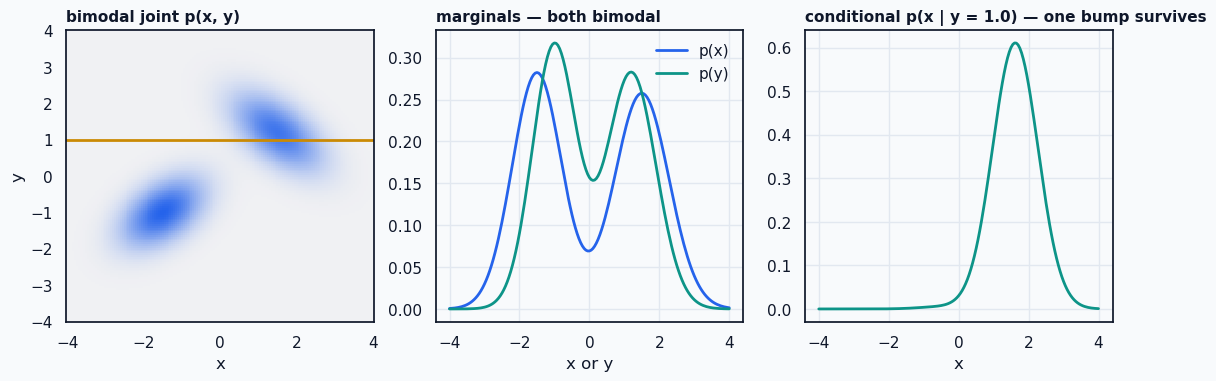

All checks passed ✓


In [8]:
# ---- Solution A
px_bi = P_bimodal.sum(axis=0) * DY
py_bi = P_bimodal.sum(axis=1) * DX
j = int(np.argmin(np.abs(GY - y_star_A)))
px_given_y_bi = P_bimodal[j, :] / (P_bimodal[j, :].sum() * DX)
# (equivalently: px_given_y_bi, _, _ = conditional_x_given_y(P_bimodal, y_star_A))

assert np.isclose(px_bi.sum() * DX, 1.0, atol=1e-3) and np.isclose(py_bi.sum() * DY, 1.0, atol=1e-3)
assert np.isclose(px_given_y_bi.sum() * DX, 1.0, atol=1e-6)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
axes[0].pcolormesh(GX, GY, P_bimodal, cmap=SEQ_CMAP, shading="auto", rasterized=True); axes[0].grid(False)
axes[0].axhline(y_star_A, color=ROLE["highlight"], lw=2); axes[0].set_title("bimodal joint p(x, y)"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[1].plot(GX, px_bi, color=ROLE["data"], label="p(x)"); axes[1].plot(GY, py_bi, color=ROLE["fit"], label="p(y)")
axes[1].legend(); axes[1].set_title("marginals — both bimodal"); axes[1].set_xlabel("x or y")
axes[2].plot(GX, px_given_y_bi, color=ROLE["posterior"]); axes[2].set_title(f"conditional p(x | y = {y_star_A}) — one bump survives"); axes[2].set_xlabel("x")
show(fig, "exA-bimodal")
print("All checks passed ✓")

## 3. Expectation

The **expected value** of a function $g$ of a random variable is its probability-weighted average,

$$E[g(X)] = \sum_x g(x)\,p(x) \qquad\text{or}\qquad E[g(X)] = \int g(x)\,p(x)\,dx ,$$

and it is what the sample average of $g$ converges to as the number of samples grows.

### Demo 3.1 — Expectation as the limit of a sample average

A die with a chosen probability mass function. Left: $p(x)$. Right: the running average of $g(X)$ over
samples against the exact $E[g(X)]$. Try $g(x) = x^2$ and notice $E[X^2] \neq (E[X])^2$.

In [9]:
DICE = {
    "fair die": np.ones(6) / 6,
    "loaded toward 6": np.array([1, 1, 1, 1, 1, 5]) / 10,
    "only 1 or 6": np.array([0.5, 0, 0, 0, 0, 0.5]),
}
G_FUNCS = {"g(x) = x": lambda x: x, "g(x) = x²": lambda x: x**2, "g(x) = (x − E[X])²  (variance)": None}
FACES = np.arange(1, 7)

def expectation_demo(die="fair die", g="g(x) = x", n_samples=500, save=None):
    p = DICE[die]
    EX = np.sum(FACES * p)
    gf = G_FUNCS[g] if G_FUNCS[g] is not None else (lambda x: (x - EX)**2)
    Eg = np.sum(gf(FACES) * p)                                   # exact:  Σ g(x) p(x)
    samples = np.random.default_rng(1).choice(FACES, size=n_samples, p=p)
    running = np.cumsum(gf(samples)) / np.arange(1, n_samples + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw=dict(width_ratios=[1, 2]))
    ax1.bar(FACES, p, color=ROLE["data"], width=0.7); ax1.set_xlabel("x (face)"); ax1.set_ylabel("p(x)")
    ax1.set_title(f"{die}:  E[X] = {EX:.3f}"); ax1.set_ylim(0, 1)
    ax2.plot(np.arange(1, n_samples + 1), running, color=ROLE["data"], lw=1.5, label="running sample average of g(X)")
    ax2.axhline(Eg, color=ROLE["truth"], ls="--", label=f"exact E[g(X)] = Σ g(x) p(x) = {Eg:.3f}")
    ax2.set_xscale("log"); ax2.set_xlabel("number of samples N (log)"); ax2.legend(loc="upper right", fontsize=9)
    ax2.set_title(f"{g}:  after {n_samples} samples the average is {running[-1]:.3f}")
    if "x²" in g:
        ax2.text(0.02, 0.06, f"g(E[X]) = {EX**2:.2f}  ≠  E[g(X)] = {Eg:.2f}: expectation does not pass through non-linear g",
                 transform=ax2.transAxes, fontsize=9, color=ROLE["residual"])
    show(fig, save)

interactive(expectation_demo,
            die=W.Dropdown(options=list(DICE), description="die", style=_style),
            g=W.Dropdown(options=list(G_FUNCS), description="function", style=_style),
            n_samples=islider(500, 10, 20000, "N samples", step=10))

Output()

### Demo 3.2 — Linearity of expectation

Expectation is a **linear operator**: for constants $a, c$ and *any* random variables $X, Y$,

$$E[c] = c, \qquad E[aX] = a\,E[X], \qquad E[X + Y] = E[X] + E[Y].$$

The last identity needs **no independence**. Below, $X \sim \mathcal{N}(1, 1)$ and $Y \sim \mathcal{N}(2, 1.5^2)$ with
correlation $\rho$ that you control. Slide $\rho$ from $-0.9$ to $0.9$: $E[X+Y]$ stays put.
Contrast with the two *non-linear* quantities in the last rows: $E[XY]$ and $\mathrm{Var}[X+Y]$ **do** depend on $\rho$.

In [10]:
MX, MY, SX, SY = 1.0, 2.0, 1.0, 1.5

def sample_xy(rho, n, seed=2):
    cov = [[SX**2, rho * SX * SY], [rho * SX * SY, SY**2]]
    return np.random.default_rng(seed).multivariate_normal([MX, MY], cov, size=n).T

def linearity_demo(a=2.0, c=3.0, rho=0.0, n_samples=2000, save=None):
    X, Y = sample_xy(rho, n_samples)
    rows = [  # identity, exact LHS, exact RHS, sampled LHS, sampled RHS
        ("E[c] = c",                        c,                 c,                 np.mean(np.full(n_samples, c)), c),
        ("E[aX] = a·E[X]",                  a * MX,            a * MX,            np.mean(a * X),            a * np.mean(X)),
        ("E[X + Y] = E[X] + E[Y]",          MX + MY,           MX + MY,           np.mean(X + Y),            np.mean(X) + np.mean(Y)),
        ("E[XY] vs E[X]·E[Y]  (non-linear)", MX*MY + rho*SX*SY, MX * MY,           np.mean(X * Y),            np.mean(X) * np.mean(Y)),
        ("Var[X+Y] vs Var[X]+Var[Y]",       SX**2 + SY**2 + 2*rho*SX*SY, SX**2 + SY**2, np.var(X + Y),      np.var(X) + np.var(Y)),
    ]
    table = "| identity | exact LHS | exact RHS | sampled LHS | sampled RHS | holds? |\n|---|---|---|---|---|---|\n"
    for name, el, er, sl, sr in rows:
        table += f"| {name} | {el:.3f} | {er:.3f} | {sl:.3f} | {sr:.3f} | {'✓' if np.isclose(el, er) else '✗ (depends on ρ)'} |\n"
    display(Markdown(f"**ρ = {rho:.2f}, N = {n_samples}**\n\n" + table))

    rhos = np.linspace(-0.95, 0.95, 39)
    s_sum, s_prod, s_var = [], [], []
    for r in rhos:
        Xr, Yr = sample_xy(r, n_samples)
        s_sum.append(np.mean(Xr + Yr)); s_prod.append(np.mean(Xr * Yr)); s_var.append(np.var(Xr + Yr))
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
    for ax, vals, exact, name in [
        (axes[0], s_sum, np.full_like(rhos, MX + MY), "E[X + Y]   (linear: flat in ρ)"),
        (axes[1], s_prod, MX*MY + rhos*SX*SY, "E[XY]   (not linear: depends on ρ)"),
        (axes[2], s_var, SX**2 + SY**2 + 2*rhos*SX*SY, "Var[X + Y]   (depends on ρ)"),
    ]:
        ax.plot(rhos, exact, color=ROLE["truth"], ls="--", label="exact")
        ax.plot(rhos, vals, color=ROLE["data"], marker="o", ms=3, lw=1, label=f"sampled, N = {n_samples}")
        ax.axvline(rho, color=ROLE["highlight"], lw=1.5); ax.set_xlabel("correlation ρ"); ax.set_title(name)
    axes[0].axhline(MX, color=ROLE["muted"], lw=1, ls=":"); axes[0].text(-0.93, MX + 0.05, "E[X]", color=ROLE["muted"], fontsize=8)
    axes[0].axhline(MY, color=ROLE["muted"], lw=1, ls=":"); axes[0].text(-0.93, MY + 0.05, "E[Y]", color=ROLE["muted"], fontsize=8)
    axes[0].set_ylim(0, 4); axes[0].legend(loc="lower right", fontsize=8.5)
    show(fig, save)

interactive(linearity_demo,
            a=fslider(2.0, -3.0, 3.0, 0.1, "a"), c=fslider(3.0, -5.0, 5.0, 0.1, "c"),
            rho=fslider(0.0, -0.95, 0.95, 0.05, "ρ (correlation of X, Y)"),
            n_samples=islider(2000, 50, 20000, "N samples", step=50, live=False))

Output()

## 4. Bayes' Theorem

From $p(x, y) = p(x \mid y)\,p(y) = p(y \mid x)\,p(x)$ follows the most famous equation in probability:

$$\underbrace{p(y \mid x)}_{\text{posterior}} = \frac{\overbrace{p(x \mid y)}^{\text{likelihood}}\;\overbrace{p(y)}^{\text{prior}}}{\underbrace{p(x)}_{\text{evidence}}} .$$

Read it as a recipe: *what I believed before* (prior) × *how well each hypothesis explains the data* (likelihood),
then renormalise so it sums to 1 (the evidence is just that normaliser).

### Demo 4.1 — Updating beliefs about a biased coin

Unknown bias $\theta = P(\text{heads})$. Prior: $\text{Beta}(\alpha, \beta)$ ($\alpha = \beta = 1$ is uniform, "I know nothing").
Likelihood of $h$ heads in $n$ flips: $\theta^h (1-\theta)^{n-h}$. We compute the posterior **literally** as
prior × likelihood on a grid of $\theta$ values, normalised — and overlay the textbook closed form
$\text{Beta}(\alpha + h,\ \beta + n - h)$ as a check. Press ▶ to flip the coin one flip at a time.
Try a strong wrong prior (e.g. $\alpha = 20, \beta = 2$ with $\theta_\text{true} = 0.3$): it takes many flips to overturn.

In [ ]:
THETA = np.linspace(0.001, 0.999, 499); DTH = THETA[1] - THETA[0]
MAX_FLIPS = 60

def coin_update(theta_true=0.7, n_flips=20, alpha=1.0, beta=1.0, seed=0, save=None):
    flips_all = np.random.default_rng(seed).random(MAX_FLIPS) < theta_true      # fixed sequence, so ▶ is consistent
    flips = flips_all[:n_flips]; h = int(flips.sum()); n = n_flips
    prior = stats.beta(alpha, beta).pdf(THETA)
    lik = THETA**h * (1 - THETA)**(n - h)                                        # p(data | θ), up to a constant
    post = prior * lik; post = post / (post.sum() * DTH)                        # Bayes' rule on the grid
    post_closed = stats.beta(alpha + h, beta + n - h).pdf(THETA)
    mean = np.sum(THETA * post) * DTH; mode = THETA[np.argmax(post)]
    cdf = np.cumsum(post) * DTH; lo, hi = THETA[np.searchsorted(cdf, 0.025)], THETA[min(np.searchsorted(cdf, 0.975), len(THETA)-1)]

    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
    axes[0].plot(THETA, prior, color=ROLE["prior"]); axes[0].set_title(f"Prior  Beta({alpha:g}, {beta:g})")
    axes[1].plot(THETA, lik / lik.max(), color=ROLE["likelihood"]); axes[1].set_title(f"Likelihood  p(data | θ): {h} heads in {n} flips\n(scaled to peak 1)")
    axes[2].plot(THETA, post, color=ROLE["posterior"], label="prior × likelihood, normalised")
    axes[2].plot(THETA, post_closed, color=ROLE["truth"], ls=":", lw=1.3, label=f"closed form Beta({alpha+h:g}, {beta+n-h:g})")
    axes[2].axvspan(lo, hi, color=ROLE["posterior"], alpha=0.12, lw=0)
    axes[2].legend(fontsize=8, loc="upper left"); axes[2].set_title(f"Posterior  p(θ | data): mean {mean:.2f}, MAP {mode:.2f}\n95% interval [{lo:.2f}, {hi:.2f}]")
    for k in range(0, n + 1):                                                    # sequential updating, one flip at a time
        hk = int(flips[:k].sum())
        axes[3].plot(THETA, stats.beta(alpha + hk, beta + k - hk).pdf(THETA), color=ROLE["posterior"], lw=1.1,
                     alpha=0.12 + 0.88 * (k / max(n, 1))**2)
    axes[3].set_title("Posterior after each flip (0 → n, darker = later)")
    for ax in axes:
        ax.axvline(theta_true, color=ROLE["highlight"], lw=1.5, ls="--"); ax.set_xlim(0, 1); ax.set_xlabel("θ"); ax.set_ylim(bottom=0)
    axes[0].text(theta_true + 0.02, axes[0].get_ylim()[1] * 0.9, "θ true", color=ROLE["highlight"], fontsize=8)
    axes[0].set_ylabel("density")
    show(fig, save)

play = W.Play(value=20, min=0, max=MAX_FLIPS, step=1, interval=250, description="flip")
n_flips_slider = islider(20, 0, MAX_FLIPS, "n flips")
W.jslink((play, "value"), (n_flips_slider, "value"))
interactive(coin_update, per_row=3, extra=[play],
            n_flips=n_flips_slider,
            theta_true=fslider(0.7, 0.05, 0.95, 0.05, "θ true (simulates the flips)"),
            alpha=fslider(1.0, 0.5, 30.0, 0.5, "prior α"), beta=fslider(1.0, 0.5, 30.0, 0.5, "prior β"),
            seed=islider(0, 0, 20, "seed"))

Output()

### ✏️ Exercise B — The medical test puzzle (≈5 min)

A disease affects **1 in 1000** people. A test for it is very good:
if you have the disease it always comes back positive, and if you are healthy it wrongly comes back positive
only **1% of the time** (a 1% false-positive rate).

> You take the test and it is **positive**. What is the probability you actually have the disease?

Write down your gut answer first. Then compute it with Bayes' rule, with $D$ = "has the disease" and $+$ = "test positive":

$$p(D \mid +) = \frac{p(+ \mid D)\,p(D)}{p(+)}, \qquad p(+) = p(+ \mid D)\,p(D) + p(+ \mid \text{healthy})\,p(\text{healthy}).$$

In [12]:
prevalence = 1 / 1000          # p(D)
false_positive_rate = 0.01     # p(+ | healthy)
p_pos_given_disease = 1.0      # p(+ | D): the test never misses

# TODO: the evidence p(+) and the posterior p(D | +)
p_positive = None
p_disease_given_positive = None

if p_disease_given_positive is None:
    print("Fill in the TODOs, then re-run.")
else:
    print(f"p(+) = {p_positive:.4f}    p(D | +) = {p_disease_given_positive:.3f}  =  {p_disease_given_positive:.1%}")

Fill in the TODOs, then re-run.


In [13]:
# ---- Solution B
p_positive = p_pos_given_disease * prevalence + false_positive_rate * (1 - prevalence)
p_disease_given_positive = p_pos_given_disease * prevalence / p_positive
print(f"p(+) = {p_positive:.4f}    p(D | +) = {p_disease_given_positive:.3f}  =  {p_disease_given_positive:.1%}")
# Follow-up: a second, independent positive test. The posterior becomes the new prior.
prior2 = p_disease_given_positive
p_positive2 = p_pos_given_disease * prior2 + false_positive_rate * (1 - prior2)
print(f"after a second positive: p(D | +, +) = {p_pos_given_disease * prior2 / p_positive2:.1%}")

p(+) = 0.0110    p(D | +) = 0.091  =  9.1%
after a second positive: p(D | +, +) = 90.9%


Only about **9%**. Most people guess 99%. The picture below shows why: out of 10 000 people, 10 are sick
(and all test positive), but the **9 990 healthy people produce about 100 false positives** — ten times more.
The sick are outnumbered among the positives because the disease is rare. This is the *base-rate fallacy*:
the prior $p(D)$ matters as much as the test.

Slide the prevalence and the false-positive rate. Note the log axis: at low prevalence, the false-positive rate
is what determines the answer. A second positive test (right panel, dotted) changes things a lot — Bayesian
updating again, with the first posterior as the new prior.

In [ ]:
def medical_demo(prevalence=0.001, false_positive_rate=0.01, save=None):
    N = 10_000
    sick = int(round(prevalence * N)); fp = int(round(false_positive_rate * (N - sick)))
    grid = np.zeros(N); grid[:sick] = 2; grid[sick:sick + fp] = 1
    cmap = ListedColormap([ROLE["grid"], ROLE["data"], ROLE["outlier"]])
    post1 = prevalence / (prevalence + (1 - prevalence) * false_positive_rate)
    post2 = post1 / (post1 + (1 - post1) * false_positive_rate)

    cmap.set_bad(BG)
    fig, (ax, axz, ax2) = plt.subplots(1, 3, figsize=(15.5, 5), gridspec_kw=dict(width_ratios=[1, 0.5, 1.3]))
    ax.imshow(grid.reshape(100, 100), cmap=cmap, vmin=0, vmax=2, interpolation="nearest"); ax.set_axis_off()
    ax.legend(handles=[Patch(color=ROLE["outlier"], label=f"sick, test positive: {sick}"),
                       Patch(color=ROLE["data"], label=f"healthy, test positive (false alarm): {fp}"),
                       Patch(color=ROLE["grid"], label=f"healthy, test negative: {N - sick - fp}")],
              loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=9, ncol=1)
    ax.set_title(f"10 000 people, one square each\n(positives in the top rows)")
    pos = np.concatenate([np.full(sick, 2.0), np.full(fp, 1.0)]); cols = 10; nrows = max(int(np.ceil(len(pos) / cols)), 1)
    block = np.full(nrows * cols, np.nan); block[:len(pos)] = pos
    axz.imshow(block.reshape(nrows, cols), cmap=cmap, vmin=0, vmax=2, interpolation="nearest", aspect="auto"); axz.set_axis_off()
    axz.set_title(f"The {sick + fp} positives, magnified\n{sick} sick · {fp} false alarms\np(D | +) = {post1:.1%}", fontsize=9.5)

    prevs = np.logspace(-4, np.log10(0.5), 200)
    for fpr, ls in [(0.001, ":"), (0.01, "-"), (0.05, "--")]:
        ax2.plot(prevs, prevs / (prevs + (1 - prevs) * fpr), color=ROLE["muted"], ls=ls, lw=1.3, label=f"false-positive rate {fpr:g}")
    cur = prevs / (prevs + (1 - prevs) * false_positive_rate)
    ax2.plot(prevs, cur, color=ROLE["posterior"], lw=2.2, label=f"false-positive rate {false_positive_rate:.3g} (current)")
    cur2 = cur / (cur + (1 - cur) * false_positive_rate)
    ax2.plot(prevs, cur2, color=ROLE["posterior"], lw=1.5, ls=":", label="… after a 2nd positive test")
    ax2.plot([prevalence], [post1], "o", color=ROLE["highlight"], ms=9, zorder=5); ax2.plot([prevalence], [post2], "o", color=ROLE["highlight"], ms=6, mfc="none", zorder=5)
    ax2.set_xscale("log"); ax2.set_ylim(0, 1); ax2.set_xlabel("prevalence p(D)  (log scale)"); ax2.set_ylabel("p(D | positive)")
    ax2.set_title(f"p(D | +) vs prevalence\none positive: {post1:.1%}   ·   two positives: {post2:.1%}"); ax2.legend(fontsize=8.5, loc="upper left")
    show(fig, save)

interactive(medical_demo,
            prevalence=logslider(0.001, -4, np.log10(0.5), "prevalence p(D)"),
            false_positive_rate=logslider(0.01, -3, np.log10(0.3), "false-positive rate"))

Output()

## 5. A simple estimation example: linear regression

Given noisy points $(x_i, \tilde y_i)$, find the line $y = f(x; \boldsymbol\theta) = m x + b$, $\boldsymbol\theta = (m, b)$,
that minimises the sum of squared **residuals** $r_i = \tilde y_i - (m x_i + b)$:

$$E_\text{LS}(\boldsymbol\theta) = \sum_i \big\|\tilde y_i - (m x_i + b)\big\|^2 .$$

The model is **linear in the parameters**: $y = \begin{bmatrix} x & 1\end{bmatrix}\begin{bmatrix} m \\ b\end{bmatrix} = \mathbf{J}(x)\,\boldsymbol\theta$,
where $\mathbf J = \partial f / \partial \boldsymbol\theta$ is the Jacobian. Setting $\partial E_\text{LS}/\partial\boldsymbol\theta = 0$ gives the **normal equations**

$$\hat{\boldsymbol\theta} = \Big[\sum_i \mathbf J^T\!(x_i)\,\mathbf J(x_i)\Big]^{-1} \Big[\sum_i \mathbf J^T\!(x_i)\,\tilde y_i\Big].$$

### Demo 5.1 — Noisy data, the true line, and the least-squares fit

In [15]:
def make_line_data(m=0.75, b=2.0, sigma_y=0.6, n=30, sigma_x=0.0, outlier_frac=0.0, seed=478, box=(0.0, 10.0)):
    "Points on y = m x + b with Gaussian noise; optionally noise in x too, and a fraction of uniform outliers."
    r = np.random.default_rng(seed)
    x_true = r.uniform(*box, n)
    x = x_true + (r.normal(0, sigma_x, n) if sigma_x > 0 else 0.0)
    y = m * x_true + b + r.normal(0, sigma_y, n)
    is_out = np.zeros(n, bool)
    k = int(round(outlier_frac * n))
    if k:
        idx = r.choice(n, k, replace=False); is_out[idx] = True
        ylo, yhi = min(b, m * box[1] + b) - 3, max(b, m * box[1] + b) + 3
        x[idx] = r.uniform(*box, k); y[idx] = r.uniform(ylo, yhi, k)
    return x, y, is_out

def ls_fit(x, y):
    "Normal equations (slide 18)."
    J = np.column_stack([x, np.ones_like(x)])
    return np.linalg.solve(J.T @ J, J.T @ y)                 # θ̂ = (JᵀJ)⁻¹ Jᵀ ỹ

def draw_line(ax, theta, xlim=(0, 10), **kw):
    xs = np.array(xlim); ax.plot(xs, theta[0] * xs + theta[1], **kw)

def ls_fit_demo(m=0.75, b=2.0, sigma=0.6, n=30, seed=478, save=None):
    x, y, _ = make_line_data(m, b, sigma, n, seed=seed)
    theta = ls_fit(x, y)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.vlines(x, theta[0] * x + theta[1], y, color=ROLE["residual"], lw=1, alpha=0.8, label="residuals rᵢ (vertical)")
    ax.scatter(x, y, color=ROLE["data"], s=28, zorder=3, label="noisy data")
    draw_line(ax, (m, b), color=ROLE["truth"], label=f"true line  m = {m:g}, b = {b:g}")
    draw_line(ax, theta, color=ROLE["fit"], label=f"least-squares fit  m̂ = {theta[0]:.2f}, b̂ = {theta[1]:.2f}")
    ax.set_xlim(0, 10); ax.set_ylim(-1, 12); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper left", fontsize=9)
    ax.set_title(f"Σ rᵢ² = {np.sum((y - (theta[0]*x + theta[1]))**2):.2f}")
    show(fig, save)

interactive(ls_fit_demo, m=fslider(0.75, -1.0, 1.5, 0.05, "m"), b=fslider(2.0, -2.0, 6.0, 0.25, "b"),
            sigma=fslider(0.6, 0.0, 3.0, 0.1, "noise σ"), n=islider(30, 3, 200, "N points"), seed=islider(478, 0, 500, "seed"))

Output()

### Demo 5.2 — Deriving the gradient with PyTorch, then descending it

Instead of solving the normal equations in closed form, we can *walk downhill* on $E_\text{LS}$. We need the gradient.
By hand, using the chain rule on $E = \sum_i (\tilde y_i - \mathbf J_i\boldsymbol\theta)^2$:

$$\frac{\partial E_\text{LS}}{\partial \boldsymbol\theta} = -2 \sum_i \mathbf J_i^T\,(\tilde y_i - \mathbf J_i \boldsymbol\theta)
\quad\Longleftrightarrow\quad
\frac{\partial E}{\partial m} = -2\sum_i x_i\, r_i, \qquad \frac{\partial E}{\partial b} = -2\sum_i r_i .$$

PyTorch's **autograd** does this for us: write the loss as ordinary tensor code with `requires_grad=True` on $\boldsymbol\theta$,
call `.backward()`, and read $\partial E/\partial\boldsymbol\theta$ from `theta.grad`.

In [16]:
x, y, _ = make_line_data()                       # default data set used for the rest of this section
xt, yt = torch.tensor(x), torch.tensor(y)        # float64 tensors

def E_LS(theta, x, y):
    "Sum of squared vertical residuals, as a torch expression of θ = (m, b)."
    m, b = theta[0], theta[1]
    return ((y - (m * x + b)) ** 2).sum()

theta = torch.tensor([0.0, 0.0], dtype=torch.float64, requires_grad=True)
E = E_LS(theta, xt, yt)
E.backward()                                     # autograd: fills theta.grad with ∂E/∂θ at θ = (0, 0)

J = np.column_stack([x, np.ones_like(x)])
grad_by_hand = -2 * J.T @ (y - J @ theta.detach().numpy())

print("E_LS(0, 0)          =", f"{E.item():.3f}")
print("autograd  ∂E/∂(m,b) =", np.round(theta.grad.numpy(), 4))
print("by hand   ∂E/∂(m,b) =", np.round(grad_by_hand, 4))
print("closed-form θ̂       =", np.round(ls_fit(x, y), 4))

E_LS(0, 0)          = 1009.554
autograd  ∂E/∂(m,b) = [-1807.7424  -324.3292]
by hand   ∂E/∂(m,b) = [-1807.7424  -324.3292]
closed-form θ̂       = [0.8033 1.6654]


**Gradient descent**: $\boldsymbol\theta \leftarrow \boldsymbol\theta - \eta\,\nabla E(\boldsymbol\theta)$, repeated.
We use the *mean* squared error (dividing by $N$ does not move the minimiser, but keeps $\eta$ at a sane scale).

Two ways to write the same loop — the first spells out the update rule, the second uses `torch.optim.SGD`, which
does exactly that update for you (and generalises to momentum, Adam, … by changing one line):

In [ ]:
def E_MSE(theta, x, y):
    return E_LS(theta, x, y) / len(x)

def gd_manual(loss_fn, x, y, lr=0.02, steps=200, theta0=(0.0, 0.0)):
    "Gradient descent with the update written out by hand."
    theta = torch.tensor(theta0, dtype=torch.float64, requires_grad=True)
    path, losses = [theta.detach().numpy().copy()], []
    for _ in range(steps):
        loss = loss_fn(theta, x, y)
        loss.backward()                       # ∂loss/∂θ  ->  theta.grad
        with torch.no_grad():
            theta -= lr * theta.grad          # θ ← θ − η ∇E      (the update rule)
        theta.grad.zero_()                    # grads accumulate by default: reset for the next step
        path.append(theta.detach().numpy().copy()); losses.append(loss.item())
    return np.array(path), np.array(losses)

def gd_optim(loss_fn, x, y, lr=0.02, steps=200, theta0=(0.0, 0.0)):
    "The same, using torch.optim.SGD (swap in torch.optim.Adam etc. to change the update rule)."
    theta = torch.tensor(theta0, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.SGD([theta], lr=lr)
    path, losses = [theta.detach().numpy().copy()], []
    for _ in range(steps):
        opt.zero_grad()                       # reset grads
        loss = loss_fn(theta, x, y)
        loss.backward()                       # compute grads
        opt.step()                            # θ ← θ − η ∇E, done by the optimizer
        path.append(theta.detach().numpy().copy()); losses.append(loss.item())
    return np.array(path), np.array(losses)

def gd_demo(lr=0.02, steps=200, save=None):
    path_m, loss_m = gd_manual(E_MSE, xt, yt, lr, steps)
    path_o, loss_o = gd_optim(E_MSE, xt, yt, lr, steps)
    theta_hat = ls_fit(x, y); mse_hat = np.mean((y - J @ theta_hat)**2)
    diverged = not np.all(np.isfinite(path_m))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    ax = axes[0]; ax.scatter(x, y, color=ROLE["data"], s=18, zorder=3)
    for i in np.unique(np.linspace(0, steps, 12).astype(int)):
        draw_line(ax, np.clip(path_m[i], -50, 50), color=ROLE["fit"], lw=1, alpha=0.15 + 0.85 * (i / steps)**1.5)
    draw_line(ax, (0.75, 2.0), color=ROLE["truth"], lw=1.5, ls="--", label="true line")
    draw_line(ax, theta_hat, color=ROLE["truth"], lw=1.5, label="closed form θ̂")
    ax.set_xlim(0, 10); ax.set_ylim(-1, 12); ax.set_title("Fitted line during descent (darker = later)"); ax.legend(fontsize=8, loc="upper left")
    ax = axes[1]; ax.plot(loss_m, color=ROLE["fit"], label="manual update"); ax.plot(loss_o, color=ROLE["highlight"], ls="--", label="torch.optim.SGD")
    ax.axhline(mse_hat, color=ROLE["truth"], ls=":", label=f"minimum (closed form) = {mse_hat:.3f}")
    ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("mean squared error"); ax.legend(fontsize=8)
    ax.set_title("Loss" + ("  — DIVERGED: learning rate too large" if diverged else f"  — final {loss_m[-1]:.3f}"))
    ax = axes[2]
    mm = np.linspace(theta_hat[0] - 1.3, theta_hat[0] + 1.3, 120); bb = np.linspace(theta_hat[1] - 8, theta_hat[1] + 8, 120)
    MM, BB = np.meshgrid(mm, bb)
    L = np.mean((y[None, None, :] - (MM[..., None] * x + BB[..., None]))**2, axis=-1)
    ax.contour(MM, BB, L, levels=np.geomspace(L.min() + 1e-3, L.max(), 14), cmap=SEQ_CMAP, linewidths=0.8)
    ax.plot(path_m[:, 0], path_m[:, 1], color=ROLE["fit"], lw=1.5, label="manual update")
    ax.plot(path_o[:, 0], path_o[:, 1], color=ROLE["highlight"], lw=1.2, ls="--", label="torch.optim.SGD")
    ax.plot(*path_m[0], "o", color=ROLE["truth"], ms=6); ax.plot(*theta_hat, "*", color=ROLE["truth"], ms=14, label="closed form θ̂")
    ax.set_xlim(mm[0], mm[-1]); ax.set_ylim(bb[0], bb[-1]); ax.set_xlabel("m"); ax.set_ylabel("b"); ax.legend(fontsize=8, loc="lower right")
    ax.set_title(f"E_MSE(m, b): a long narrow bowl  ·  paths differ by {np.nanmax(np.abs(path_m - path_o)):.1e}")
    show(fig, save)

interactive(gd_demo, lr=fslider(0.02, 0.001, 0.04, 0.001, "learning rate η"), steps=islider(200, 1, 600, "steps"))

Output()

Note the two descents coincide exactly: `torch.optim.SGD` *is* the manual update. The bowl is long and narrow
because $m$ multiplies $x \in [0, 10]$ while $b$ multiplies 1 — the loss is far more sensitive to $m$. That is why
$\eta \gtrsim 0.03$ diverges in the $m$ direction while $b$ still crawls. (Centring $x$ would fix the conditioning.)

**Weighted least squares** (slide 18): if some points are less certain than others, weight each residual by
the inverse of its variance, $E_\text{WLS} = \sum_i \sigma_i^{-2}\,\|r_i\|^2$; the normal equations become
$\hat{\boldsymbol\theta} = [\sum_i \sigma_i^{-2}\mathbf J_i^T\mathbf J_i]^{-1}[\sum_i \sigma_i^{-2}\mathbf J_i^T \tilde y_i]$.
In autograd terms it is a one-line change to the loss — which is the theme of the next exercise.

### ✏️ Exercise C — What if the error is *perpendicular* to the line? (≈10 min)

The residual on slide 19 is **vertical**: it assumes all the noise is in $y$ and $x$ is exact. If both coordinates
are measured (a sensor returning points in the plane), the natural error is the **perpendicular distance** from
each point to the line,

$$d_i = \frac{|\tilde y_i - (m x_i + b)|}{\sqrt{1 + m^2}}, \qquad E_\perp(\boldsymbol\theta) = \frac1N\sum_i d_i^2 .$$

1. Implement `E_perp` below. It is one line different from `E_MSE` — and because we use autograd, **nothing else changes**:
   the same `gd_manual` loop minimises it.
2. Think: is $E_\perp$ quadratic in $\boldsymbol\theta$? (Hint: the $1/(1+m^2)$ factor.) Can you write normal equations for it?
3. Run the demo below. It compares your gradient-descent solution with the closed-form *total least squares* answer
   (the line's normal is the direction of least variance of the centred points: the last right-singular vector of the centred data matrix),
   and shows what happens to the ordinary fit when $x$ is noisy.

In [18]:
def E_perp(theta, x, y):
    "Mean squared PERPENDICULAR distance from the points to the line y = m x + b."
    m, b = theta[0], theta[1]
    # TODO: replace the vertical residual with the perpendicular distance
    #       d_i = |y_i - (m x_i + b)| / sqrt(1 + m²)      (torch.sqrt works on tensors)
    return E_MSE(theta, x, y)      # placeholder — currently identical to the vertical (ordinary) loss

In [19]:
# ---- Solution C
def E_perp(theta, x, y):
    "Mean squared PERPENDICULAR distance from the points to the line y = m x + b."
    m, b = theta[0], theta[1]
    d = (y - (m * x + b)) / torch.sqrt(1 + m**2)
    return (d ** 2).mean()

# 2. Not quadratic in θ: the residual is divided by sqrt(1 + m²), so ∂E/∂θ = 0 is no longer a LINEAR system in (m, b)
#    and there are no normal equations of the slide-18 form. Gradient descent does not care. There *is* a closed form,
#    but via the SVD (total least squares) rather than via linear normal equations — see tls_fit below.

In [20]:
def tls_fit(x, y):
    "Total least squares: the line minimising perpendicular distances, in closed form via the SVD."
    X = np.column_stack([x - x.mean(), y - y.mean()])
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    nx, ny = Vt[-1]                                     # unit normal to the line = direction of least variance
    m = -nx / ny; b = y.mean() - m * x.mean()
    return np.array([m, b])

def perp_demo(sigma_x=1.5, sigma_y=1.5, m_true=2.0, n=60, seed=3, save=None):
    b_true = 1.0
    xd, yd, _ = make_line_data(m_true, b_true, sigma_y, n, sigma_x=sigma_x, seed=seed)
    th_ols = ls_fit(xd, yd); th_tls = tls_fit(xd, yd)
    path, _ = gd_manual(E_perp, torch.tensor(xd), torch.tensor(yd), lr=0.02, steps=400, theta0=tuple(th_ols))
    th_gd = path[-1]

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw=dict(width_ratios=[1, 1.2]))
    ax.scatter(xd, yd, color=ROLE["data"], s=22, zorder=3, label="data (noise in x AND y)")
    draw_line(ax, (m_true, b_true), xlim=(-3, 13), color=ROLE["truth"], label=f"true line, m = {m_true:g}")
    draw_line(ax, th_ols, xlim=(-3, 13), color=ROLE["residual"], label=f"ordinary LS (vertical error), m̂ = {th_ols[0]:.2f}")
    draw_line(ax, th_gd, xlim=(-3, 13), color=ROLE["fit"], label=f"perpendicular error, gradient descent, m̂ = {th_gd[0]:.2f}")
    draw_line(ax, th_tls, xlim=(-3, 13), color=ROLE["truth"], ls=":", lw=1.3, label=f"perpendicular error, closed form (SVD), m̂ = {th_tls[0]:.2f}")
    # residual segments for a few points: vertical (to OLS line) vs perpendicular (to TLS line)
    for i in np.linspace(0, n - 1, 6).astype(int):
        ax.plot([xd[i], xd[i]], [yd[i], th_ols[0] * xd[i] + th_ols[1]], color=ROLE["residual"], lw=1)
        m_, b_ = th_gd; xf = (xd[i] + m_ * (yd[i] - b_)) / (1 + m_**2)
        ax.plot([xd[i], xf], [yd[i], m_ * xf + b_], color=ROLE["fit"], lw=1)
    ax.set_xlim(-3, 13); ax.set_ylim(-6, 28); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8, loc="upper left")
    ax.set_title("Vertical residuals pull the slope down when x is noisy")

    sxs = np.linspace(0, 3, 13); ols_m, tls_m = [], []
    for sx in sxs:
        o, t = [], []
        for s in range(25):
            xs_, ys_, _ = make_line_data(m_true, b_true, sigma_y, n, sigma_x=sx, seed=100 + s)
            o.append(ls_fit(xs_, ys_)[0]); t.append(tls_fit(xs_, ys_)[0])
        ols_m.append(np.mean(o)); tls_m.append(np.mean(t))
    var_x = 10**2 / 12                                                     # variance of x ~ Uniform(0, 10)
    ax2.axhline(m_true, color=ROLE["truth"], label="true slope")
    ax2.plot(sxs, ols_m, "o-", color=ROLE["residual"], ms=4, label="ordinary LS (vertical), mean over 25 data sets")
    ax2.plot(sxs, m_true * var_x / (var_x + sxs**2), color=ROLE["residual"], ls="--", lw=1, label="theory: m · Var[x] / (Var[x] + σx²)")
    ax2.plot(sxs, tls_m, "o-", color=ROLE["fit"], ms=4, label="perpendicular (TLS), mean over 25 data sets")
    ax2.axvline(sigma_x, color=ROLE["highlight"], lw=1.5)
    ax2.set_xlabel("noise in x,  σx"); ax2.set_ylabel("estimated slope m̂"); ax2.legend(fontsize=8.5, loc="lower left")
    ax2.set_title(f"Regression dilution: OLS slope shrinks with σx (σy = {sigma_y:g} fixed)")
    show(fig, save)

interactive(perp_demo, sigma_x=fslider(1.5, 0.0, 3.0, 0.1, "σx (noise in x)"), sigma_y=fslider(1.5, 0.1, 3.0, 0.1, "σy (noise in y)"),
            m_true=fslider(2.0, 0.25, 3.0, 0.25, "true slope m"), n=islider(60, 10, 300, "N points"), seed=islider(3, 0, 50, "seed"))

Output()

**Discussion.** Neither loss is "right" in general — the loss encodes an assumption about *where the noise is*.
Vertical residuals are correct when $x$ is exact; perpendicular residuals are correct when the noise is
isotropic (equal in $x$ and $y$; try $\sigma_x \ne \sigma_y$ above and the perpendicular fit is biased too).
Weighted least squares is the same idea with per-point noise levels. This is the statistical motivation the
slides mention: least squares is *maximum likelihood under Gaussian noise in the residual you chose*.

## 6. Dealing with outliers: RANSAC

An **outlier** is an observation far from the others — a gross error rather than Gaussian noise. Squared
error is brutal here: one point 10 units off contributes as much as 100 points 1 unit off.

### Demo 6.1 — Outliers pull the line down (slide 24)

In [21]:
def outlier_demo(outlier_frac=0.3, seed=478, save=None):
    xo, yo, is_out = make_line_data(outlier_frac=outlier_frac, seed=seed)
    th_all = ls_fit(xo, yo); th_clean = ls_fit(xo[~is_out], yo[~is_out])
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(xo[~is_out], yo[~is_out], color=ROLE["data"], s=28, zorder=3, label="inliers")
    ax.scatter(xo[is_out], yo[is_out], color=ROLE["outlier"], s=36, marker="X", zorder=3, label="outliers")
    draw_line(ax, (0.75, 2.0), color=ROLE["truth"], label="true line")
    draw_line(ax, th_all, color=ROLE["residual"], ls="--", label=f"LS on all points:  m̂ = {th_all[0]:.2f}, b̂ = {th_all[1]:.2f}")
    draw_line(ax, th_clean, color=ROLE["fit"], label=f"LS on inliers only: m̂ = {th_clean[0]:.2f}, b̂ = {th_clean[1]:.2f}")
    ax.set_xlim(0, 10); ax.set_ylim(-2, 13); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=9, loc="upper left")
    ax.set_title(f"{int(is_out.sum())} of {len(xo)} points are outliers")
    show(fig, save)

interactive(outlier_demo, outlier_frac=fslider(0.3, 0.0, 0.7, 0.05, "outlier fraction"), seed=islider(478, 0, 500, "seed"))

Output()

### Demo 6.2 — RANSAC: RAndom SAmple Consensus (Fischler & Bolles, 1981)

The idea: a *minimal* sample (2 points for a line) is either all inliers — in which case the model it defines
will be supported by many other points — or it contains an outlier and gets little support. So:

1. Determine the smallest number of points $n$ that fits the model (a line: $n = 2$).
2. Draw $n$ points at random and fit the model to them.
3. Count the points within a tolerance $t$ of that model (the **consensus set**).
4. If the consensus set is large enough, stop — and refit the model to the whole consensus set.
5. Otherwise repeat 2–4, up to $k$ iterations, keeping the best model seen.

We measure point-to-line distance **perpendicularly** (Exercise C!): a vertical tolerance would let steep
candidate lines collect inliers far too easily.

In [22]:
def line_from_two_points(p, q):
    if np.isclose(p[0], q[0]):
        return None                                        # vertical: skip (cannot be written y = m x + b)
    m = (q[1] - p[1]) / (q[0] - p[0])
    return np.array([m, p[1] - m * p[0]])

def perp_distance(theta, x, y):
    return np.abs(y - (theta[0] * x + theta[1])) / np.sqrt(1 + theta[0]**2)

def ransac_line(x, y, tol=0.8, n_iters=50, consensus_frac=0.6, seed=0):
    "Returns (refined θ, inlier mask, history). history[i] = (sample indices, candidate θ, inlier mask, best-so-far θ)."
    rng = np.random.default_rng(seed)
    n_min, N = 2, len(x)                                                        # step 1
    best_theta, best_inliers, history = None, np.zeros(N, bool), []
    for _ in range(n_iters):
        idx = rng.choice(N, n_min, replace=False)                               # step 2: minimal random sample
        theta = line_from_two_points((x[idx[0]], y[idx[0]]), (x[idx[1]], y[idx[1]]))
        if theta is None:
            continue
        inliers = perp_distance(theta, x, y) < tol                              # step 3: consensus set
        if inliers.sum() > best_inliers.sum():
            best_theta, best_inliers = theta, inliers
        history.append((idx, theta, inliers, best_theta))
        if best_inliers.sum() >= consensus_frac * N:                            # step 4: enough support -> stop
            break
    refined = ls_fit(x[best_inliers], y[best_inliers])                          # "and then improve the model"
    return refined, best_inliers, history

In [ ]:
def ransac_demo(outlier_frac=0.4, tol=0.8, n_iters=50, consensus_frac=0.6, seed=0, show_iter=200, save=None):
    xo, yo, is_out = make_line_data(outlier_frac=outlier_frac, seed=478)
    refined, final_inliers, hist = ransac_line(xo, yo, tol, n_iters, consensus_frac, seed)
    k = min(show_iter, len(hist) - 1); idx, theta, inliers, best = hist[k]
    th_all = ls_fit(xo, yo)

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))
    xs = np.array([0, 10]); band = tol * np.sqrt(1 + theta[0]**2)
    ax.fill_between(xs, theta[0] * xs + theta[1] - band, theta[0] * xs + theta[1] + band, color=ROLE["highlight"], alpha=0.12, lw=0, label=f"tolerance band ±{tol:g}")
    ax.scatter(xo[~inliers], yo[~inliers], color=ROLE["muted"], s=22, label="outside tolerance")
    ax.scatter(xo[inliers], yo[inliers], color=ROLE["inlier"], s=28, zorder=3, label=f"consensus set: {inliers.sum()} points")
    ax.scatter(xo[idx], yo[idx], s=160, facecolor="none", edgecolor=ROLE["highlight"], lw=2.2, zorder=4, label="the 2 sampled points")
    draw_line(ax, theta, color=ROLE["highlight"], lw=1.8, label="candidate line from the sample")
    if best is not None:
        best_count = max(int(h[2].sum()) for h in hist[:k + 1])
        draw_line(ax, best, color=ROLE["fit"], ls="--", lw=1.5, label=f"best so far ({best_count} inliers)")
    draw_line(ax, (0.75, 2.0), color=ROLE["truth"], lw=1.2, label="true line")
    ax.set_xlim(0, 10); ax.set_ylim(-2, 13); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8, loc="upper left")
    stopped = f"stopped early at {len(hist)} (consensus ≥ {consensus_frac:.0%})" if len(hist) < n_iters else f"ran all {n_iters}"
    ax.set_title(f"Iteration {k + 1} of {len(hist)}  ·  {stopped}")

    ax2.scatter(xo[~final_inliers], yo[~final_inliers], color=ROLE["outlier"], s=30, marker="X", label=f"rejected as outliers: {int((~final_inliers).sum())}  (true: {int(is_out.sum())})")
    ax2.scatter(xo[final_inliers], yo[final_inliers], color=ROLE["inlier"], s=28, zorder=3, label=f"final consensus set: {int(final_inliers.sum())}")
    draw_line(ax2, (0.75, 2.0), color=ROLE["truth"], label="true line  m = 0.75, b = 2")
    draw_line(ax2, th_all, color=ROLE["residual"], ls="--", label=f"LS on all points  m̂ = {th_all[0]:.2f}, b̂ = {th_all[1]:.2f}")
    draw_line(ax2, refined, color=ROLE["fit"], label=f"RANSAC + LS refit  m̂ = {refined[0]:.2f}, b̂ = {refined[1]:.2f}")
    ax2.set_xlim(0, 10); ax2.set_ylim(-2, 13); ax2.set_xlabel("x"); ax2.legend(fontsize=8, loc="upper left")
    ax2.set_title("Final result (slide 25): outlier-free fit")
    show(fig, save)

play_r = W.Play(value=200, min=0, max=200, step=1, interval=400, description="iterate")
iter_slider = islider(200, 0, 200, "show iteration (capped at the last one)")
W.jslink((play_r, "value"), (iter_slider, "value"))
interactive(ransac_demo, per_row=3, extra=[play_r],
            show_iter=iter_slider,
            outlier_frac=fslider(0.4, 0.0, 0.8, 0.05, "outlier fraction (1 − w)"),
            tol=fslider(0.8, 0.1, 4.0, 0.1, "tolerance t"),
            n_iters=islider(50, 1, 200, "max iterations k"),
            consensus_frac=fslider(0.6, 0.1, 1.0, 0.05, "consensus threshold (fraction of N)"),
            seed=islider(0, 0, 50, "RANSAC seed"))

Output()

### Demo 6.3 — RANSAC by the numbers (slides 21–22)

RANSAC has three parameters: the tolerance $t$, the number of iterations $k$, and the consensus threshold.
How many iterations do we need? Let $w$ be the probability that a randomly drawn point is an inlier and $n$ the
minimal sample size. A sample is outlier-free with probability $b = w^n$.

- **Expected number of trials** until the first clean sample (slide 21): the count is geometric with success
  probability $b$, so $E[k] = b + 2(1-b)b + 3(1-b)^2 b + \dots = 1/b = w^{-n}$.
- **Guaranteeing success** (slide 22): the probability that $k$ trials *all* fail is $(1 - w^n)^k$. To have at least one
  clean sample with probability $z$ we need $1 - (1 - w^n)^k \ge z$, i.e.

$$k = \frac{\log(1 - z)}{\log(1 - w^n)} ,$$

which grows when we demand more confidence ($z \uparrow$), when there are more outliers ($w \downarrow$),
or when the model needs more points ($n \uparrow$). Below we check both formulas against simulation.

In [24]:
def trials_until_clean_sample(w, n, reps=400, seed=0):
    "Simulate drawing n-point samples (each point an inlier with prob. w) until all n are inliers; return the trial counts."
    rng = np.random.default_rng(seed); b = w**n
    T = int(np.clip(30 / b, 50, 100_000))                                # enough trials that failures to finish are rare
    clean = (rng.random((reps, T, n)) < w).all(axis=-1)
    first = clean.argmax(axis=1) + 1
    first[~clean.any(axis=1)] = T
    return first

def k_required(z, w, n):
    return np.log(1 - z) / np.log(1 - w**n)

W_GRID = np.linspace(0.3, 0.95, 14)
MC_MEAN = {n: np.array([trials_until_clean_sample(w, n).mean() for w in W_GRID]) for n in (2, 3, 4)}   # precomputed once

def ransac_numbers(z=0.99, w=0.6, n=2, save=None):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    ws = np.linspace(0.2, 0.99, 200)
    ax = axes[0]
    for nn, ls in [(2, "-"), (3, "--"), (4, "-."), (8, ":")]:
        ax.plot(ws, ws**(-nn), color=ROLE["truth"], ls=ls, lw=1.2, label=f"theory w⁻ⁿ, n = {nn}")
        if nn in MC_MEAN:
            ax.plot(W_GRID, MC_MEAN[nn], "o", color=ROLE["data"], ms=4)
    ax.plot([], [], "o", color=ROLE["data"], ms=4, label="simulation (400 runs each)")
    ax.set_yscale("log"); ax.set_ylim(1, 1e5); ax.set_xlabel("inlier probability w"); ax.set_ylabel("expected trials E[k]")
    ax.set_title("Expected trials to the first clean sample = w⁻ⁿ"); ax.legend(fontsize=8)

    ax = axes[1]
    for nn, ls in [(2, "-"), (3, "--"), (4, "-."), (8, ":")]:
        ax.plot(ws, k_required(z, ws, nn), color=ROLE["truth"], ls=ls, lw=1.2, label=f"n = {nn}")
    ax.plot([w], [k_required(z, w, n)], "o", color=ROLE["highlight"], ms=9, label=f"w = {w:g}, n = {n}: k = {k_required(z, w, n):.0f}")
    ax.set_yscale("log"); ax.set_ylim(1, 1e5); ax.set_xlabel("inlier probability w"); ax.set_ylabel("required iterations k")
    ax.set_title(f"k = log(1 − z) / log(1 − wⁿ)  for z = {z:g}"); ax.legend(fontsize=8)

    ax = axes[2]
    counts = trials_until_clean_sample(w, n, reps=2000, seed=1)
    kmax = int(np.percentile(counts, 99)); ks = np.arange(1, kmax + 1); b = w**n
    ax.hist(counts, bins=np.arange(0.5, kmax + 1.5), density=True, color=ROLE["data"], alpha=0.5, lw=0, label="simulation: trial of first clean sample")
    ax.plot(ks, b * (1 - b)**(ks - 1), color=ROLE["truth"], lw=1.5, label="geometric pmf b(1 − b)^(k−1)")
    ax.axvline(k_required(z, w, n), color=ROLE["highlight"], lw=1.5, label=f"k for z = {z:g}: {k_required(z, w, n):.1f}")
    frac = np.mean(counts <= k_required(z, w, n))
    ax.set_xlabel("trial index k"); ax.set_ylabel("probability"); ax.legend(fontsize=8)
    ax.set_title(f"w = {w:g}, n = {n}: mean {counts.mean():.1f} (theory {1/b:.1f});  P(success within k) = {frac:.3f} (target {z:g})")
    show(fig, save)

rows = "| w \\ n | 2 | 3 | 4 | 8 |\n|---|---|---|---|---|\n" + "\n".join(
    f"| {w:g} | " + " | ".join(f"{k_required(0.99, w, n):.0f}" for n in (2, 3, 4, 8)) + " |" for w in (0.9, 0.7, 0.5, 0.3))
display(Markdown("**Iterations k needed for z = 0.99:**\n\n" + rows))
interactive(ransac_numbers, z=fslider(0.99, 0.5, 0.999, 0.001, "success probability z"),
            w=fslider(0.6, 0.3, 0.95, 0.05, "inlier probability w"), n=W.Dropdown(options=[2, 3, 4], value=2, description="model points n", style=_style))

**Iterations k needed for z = 0.99:**

| w \ n | 2 | 3 | 4 | 8 |
|---|---|---|---|---|
| 0.9 | 3 | 4 | 4 | 8 |
| 0.7 | 7 | 11 | 17 | 78 |
| 0.5 | 16 | 34 | 71 | 1177 |
| 0.3 | 49 | 168 | 566 | 70188 |

Output()

### ✏️ Exercise D (take-home) — Break RANSAC

Go back to Demo 6.2 and find slider settings where RANSAC returns a bad line. For each of the three
parameters on slide 21, find one failure and explain it in a sentence:

1. **Tolerance $t$** too large or too small — what happens to the consensus set in each case?
2. **Iterations $k$** too few for the outlier fraction — use the slide-22 formula to predict when this starts to happen
   (with $w = 1 - $ outlier fraction and $n = 2$), then confirm it by changing the RANSAC seed.
3. **Consensus threshold** too low — why does an early stop hurt even when a clean sample was drawn?

Bonus: what if the outliers are not uniform but lie on a *second* line? (Edit `make_line_data` to place them there.)
Which of the three parameters protects you, if any?

## Takeaways (slide 26)

1. **Random variables represent uncertainty**; a density's *area* is the probability.
2. **Marginalise** by summing out; **condition** by slicing and renormalising. **Bayes' rule** is the latter, read backwards — and the prior matters (9%, not 99%).
3. **Expectation is linear** regardless of dependence; non-linear functionals are not.
4. **Least squares** is the basic estimator: closed form via the normal equations, or by descending the gradient — which autograd gives you for *any* loss, including the perpendicular one.
5. **Outliers ruin your day**: squared error has no mercy.
6. **RANSAC** finds the outlier-free model, and $k = \log(1-z)/\log(1-w^n)$ tells you how long to run it.

---
## Appendix — Static figures

Widgets do not survive export to HTML/PDF. This cell re-renders every demo at its default settings and writes each
figure as a vector PDF to `figures/02-*.pdf`.

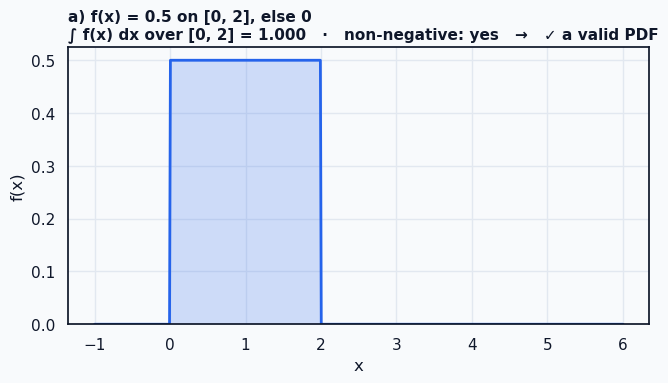

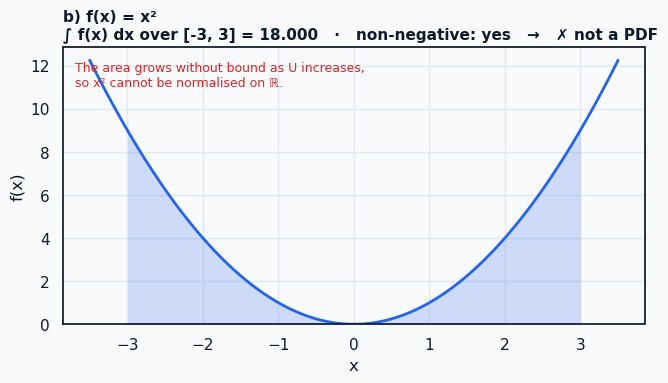

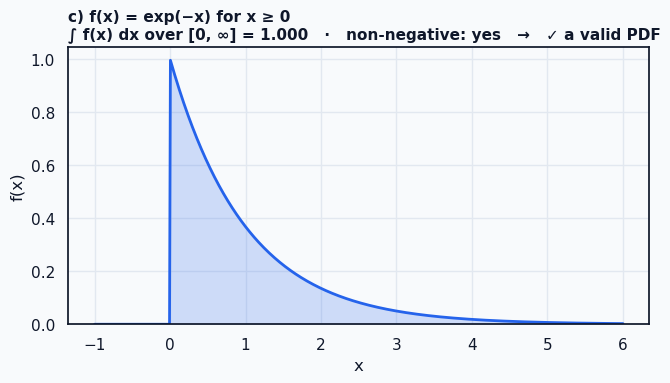

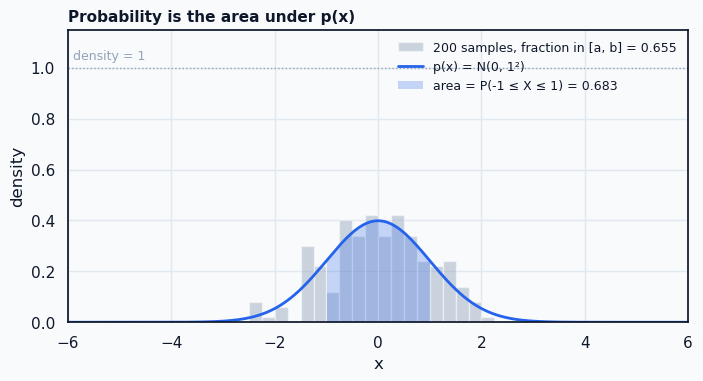

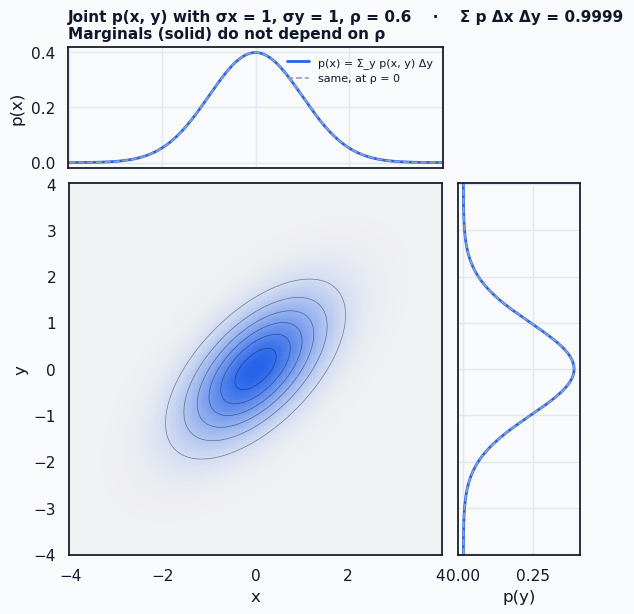

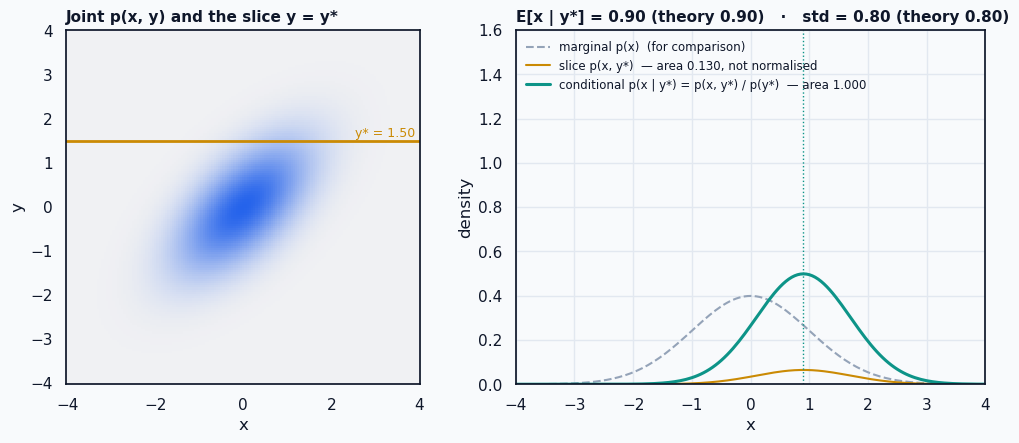

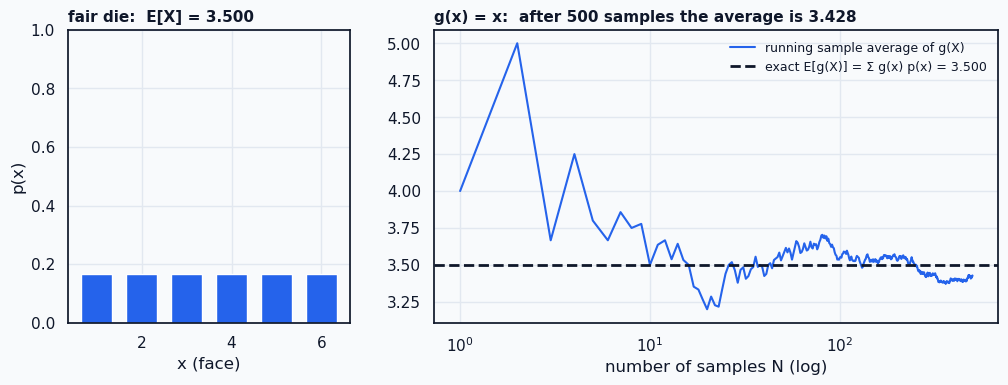

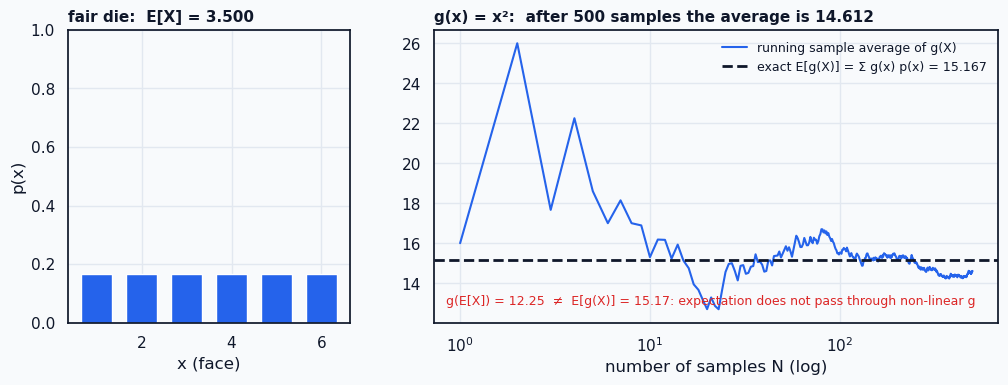

**ρ = 0.70, N = 2000**

| identity | exact LHS | exact RHS | sampled LHS | sampled RHS | holds? |
|---|---|---|---|---|---|
| E[c] = c | 3.000 | 3.000 | 3.000 | 3.000 | ✓ |
| E[aX] = a·E[X] | 2.000 | 2.000 | 2.041 | 2.041 | ✓ |
| E[X + Y] = E[X] + E[Y] | 3.000 | 3.000 | 3.047 | 3.047 | ✓ |
| E[XY] vs E[X]·E[Y]  (non-linear) | 3.050 | 2.000 | 3.157 | 2.068 | ✗ (depends on ρ) |
| Var[X+Y] vs Var[X]+Var[Y] | 5.350 | 3.250 | 5.503 | 3.325 | ✗ (depends on ρ) |


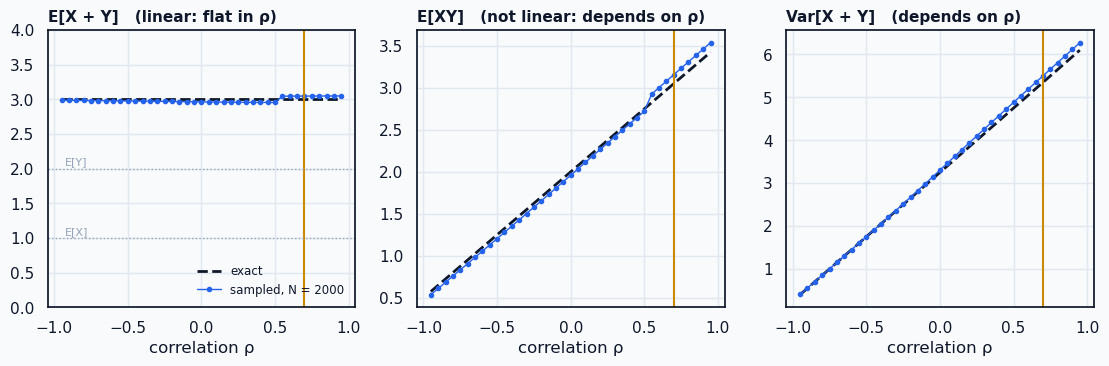

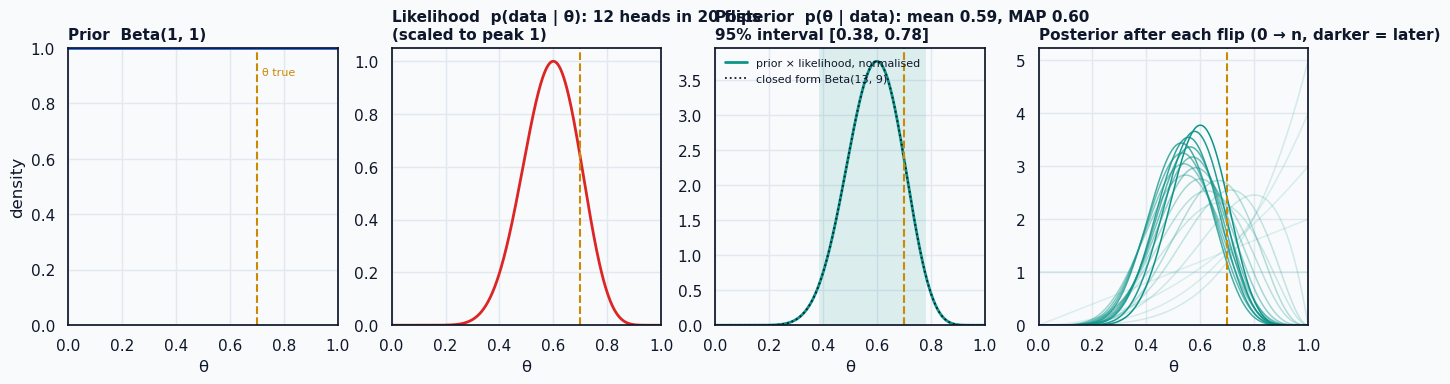

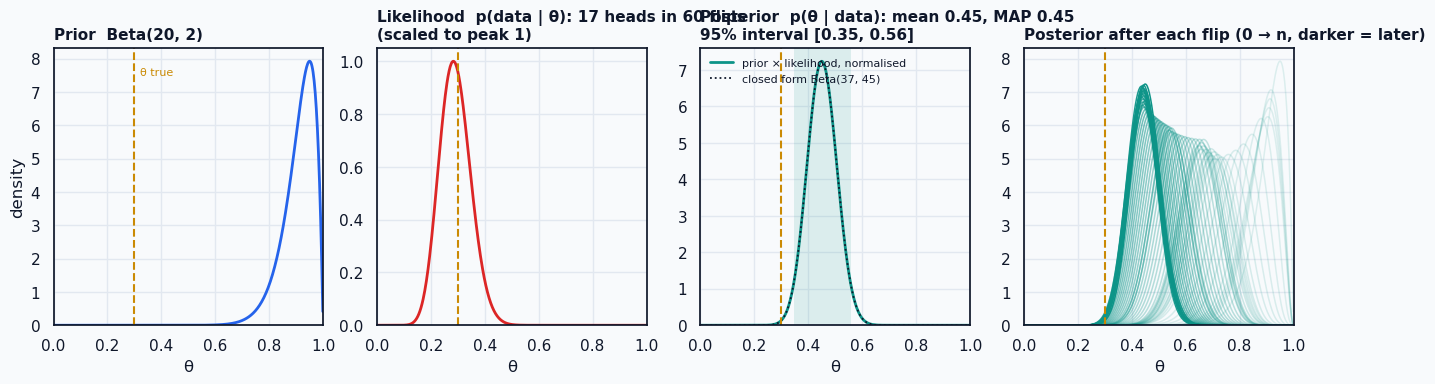

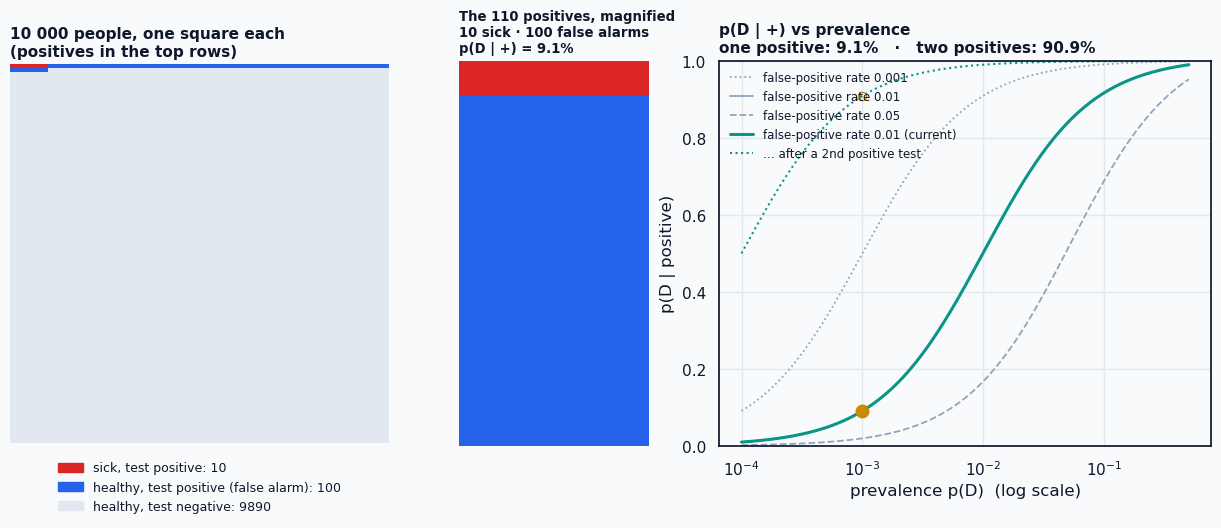

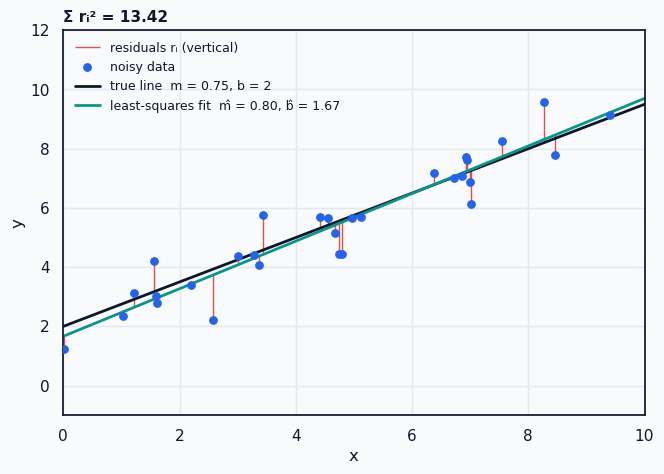

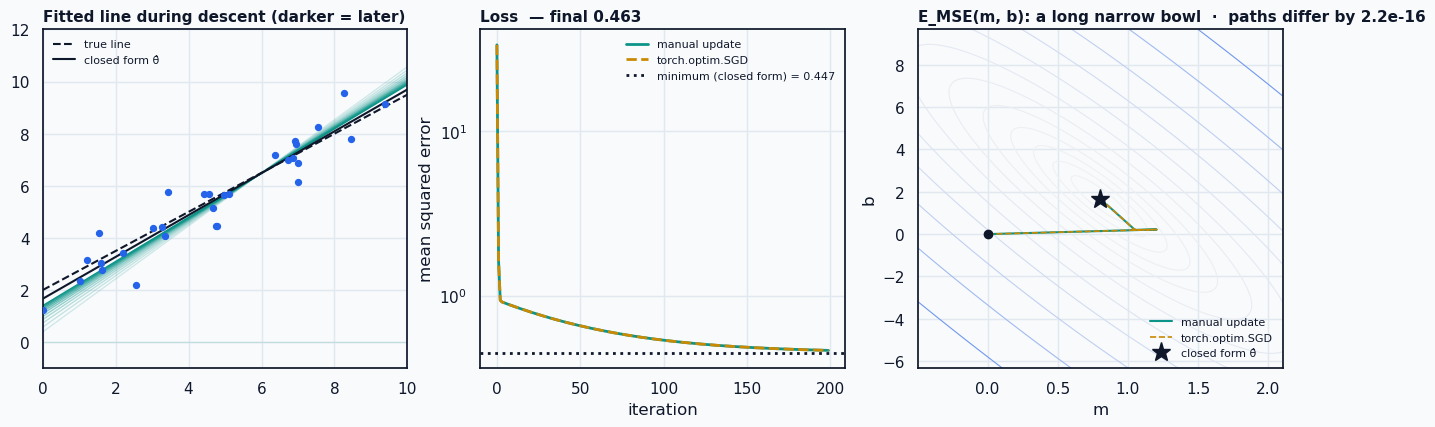

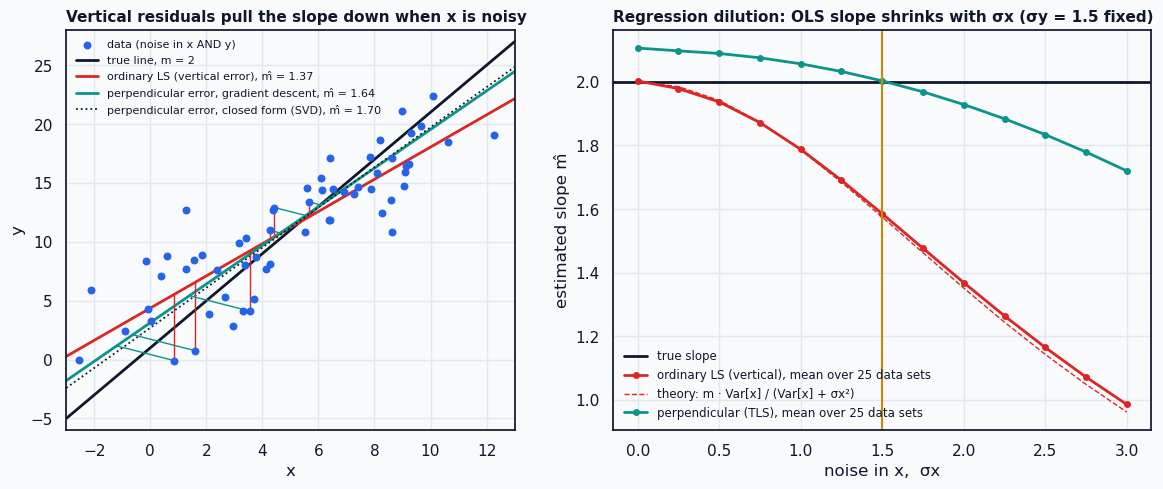

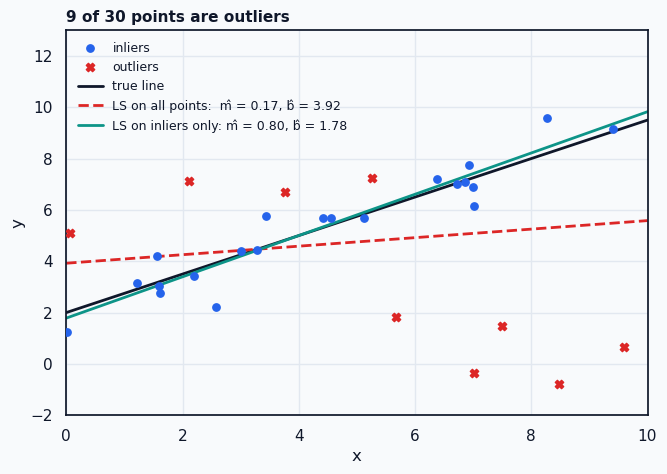

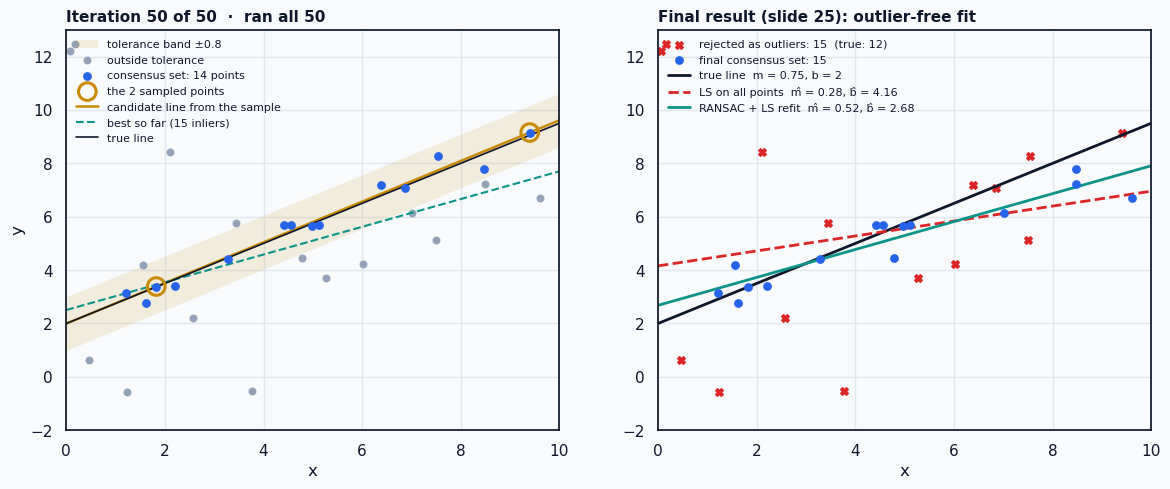

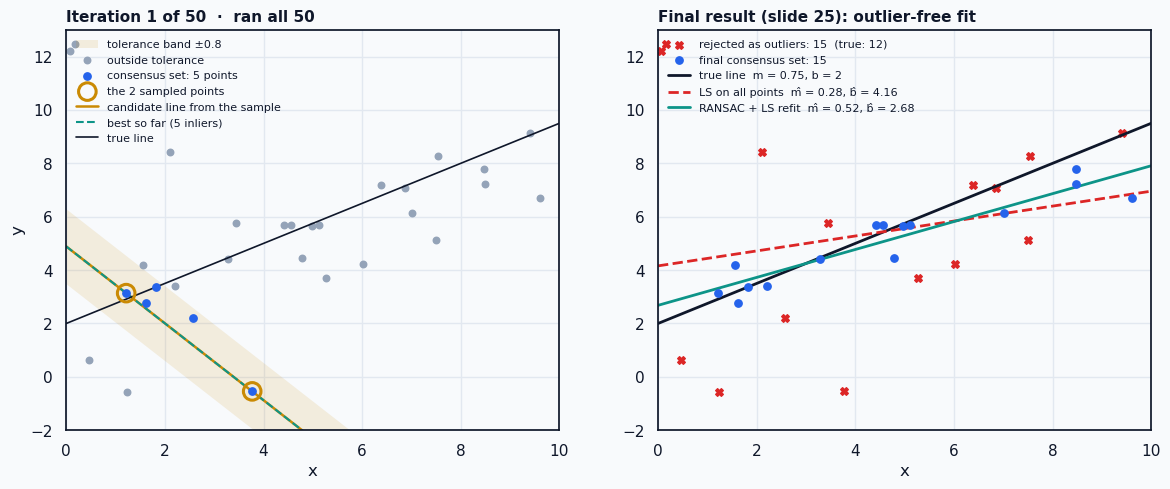

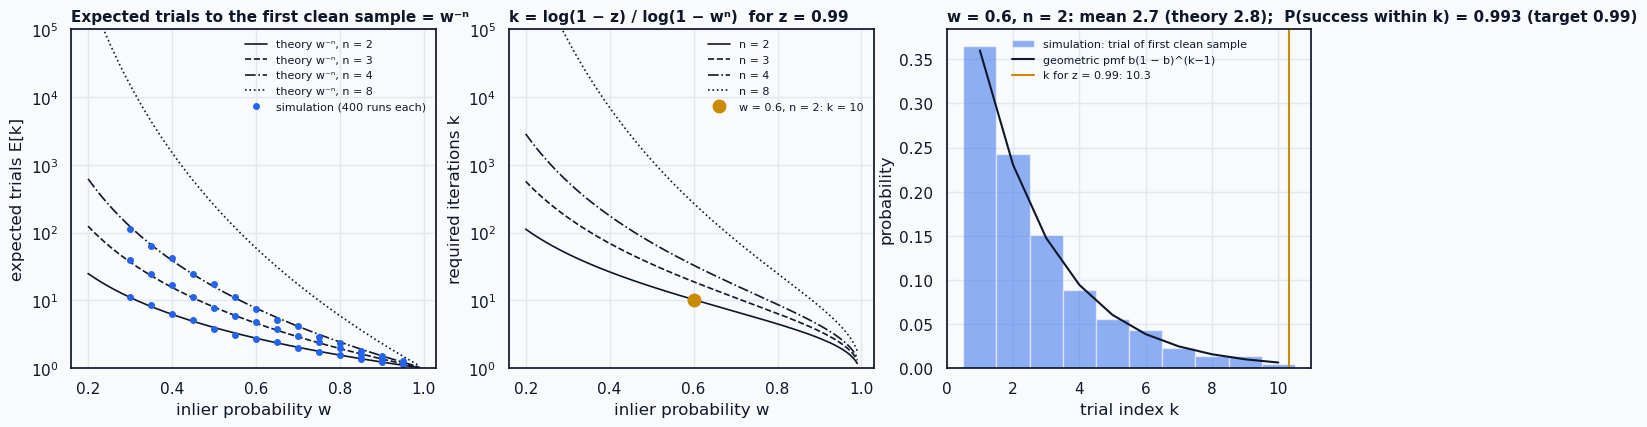

wrote 20 figures to /Users/frieda/Documents/courses/csc478/figures


In [25]:
quiz_pdf(save="quiz-a"); quiz_pdf("b) f(x) = x²", 3.0, save="quiz-b"); quiz_pdf("c) f(x) = exp(−x) for x ≥ 0", save="quiz-c")
gaussian_area(save="gaussian-area")
plot_joint(save="joint-marginals"); plot_conditional(save="conditional")
expectation_demo(save="expectation"); expectation_demo(g="g(x) = x²", save="expectation-x2")
linearity_demo(rho=0.7, save="linearity")
coin_update(save="bayes-coin"); coin_update(theta_true=0.3, alpha=20, beta=2, n_flips=60, save="bayes-coin-strong-prior")
medical_demo(save="medical-test")
ls_fit_demo(save="ls-fit"); gd_demo(save="gradient-descent"); perp_demo(save="perpendicular-error")
outlier_demo(save="outliers"); ransac_demo(save="ransac"); ransac_demo(show_iter=0, save="ransac-first-iteration")
ransac_numbers(save="ransac-numbers")
print("wrote", len(sorted(FIG_DIR.glob("02-*.pdf"))), "figures to", FIG_DIR.resolve())